# Gene level evaluation

In [1]:
import pandas as pd
from pathlib import Path
import os

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pi

## 0. Load paths

In [2]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"
CFG_DUAL = os.path.join(BASE_DIR_PROJECT, "configs/config.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [3]:
import random
import numpy as np
import torch

def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_full_reproducibility(42)

In [4]:
cfg = load_config(CFG_DUAL)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_CosmXPancreas'}), 'model': CfgNode({'n_embed': 128, 'local_component': CfgNode({'name': 'GCN', 'parameters': CfgNode({'hidden_dim': 512, 'num_layers': 1, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'parameters': CfgNode({'n_heads': 2, 'dim_feedforward': 256, 'dropout_global': 0.0, 'activation_func': 'relu', 'num_layers': 4, 'max_seq_len': 3000, 'long_range_attention': False, 'type_gex_embedding': None}), 'latent_obsm_key': None}), 'save': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/melton25/', 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'auto', 'lr': 0.005, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 40, 'lr_max_epochs': 100, 'wd': 0.01, 'loss': 'SCELoss', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'ea

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [6]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 0


In [7]:
model_name = "melton25/model"

In [8]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "melton25"), 
    adata, 
    cfg,
    model_name="model",
    local_component = True, 
    global_component = True, 
)

Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/melton25/modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [9]:
print(dual_combined_model)

## 2. Gene level evaluation

In [10]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .X


In [11]:
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', '

### Gene loadings analysis

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

In [12]:
from InterScale.evaluation import gene_loadings

In [13]:
result.layers["log1p_norm"] = result.X

In [14]:
gene_loadings(
    result,
    dual_combined_model,
    local_latent_key = "_global_emb",
    global_latent_key = "_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', '

#### Covariance analysis of embedding dimensions based on gene loadings

##### 1. Are the embedding dimensions linearly independent?

For the local and global embeddings separately: 

- Linear independence of embedding dimensions = columns of Z are linearly independent, i.e. rank(Z) == n_dims
- Visual: Plot the correlation between each embedding dimension. If the matrix is almost diagonal, we can assume linea independence. 

In [15]:
from InterScale.evaluation import latent_rank_report, pl_latent_correlation

In [16]:
# Check rank:
rep_global = latent_rank_report(result, "_global_emb")
rep_local  = latent_rank_report(result, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 386727, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 386727, 'n_dims': 128, 'rank': 128, 'linearly_independent': True}


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


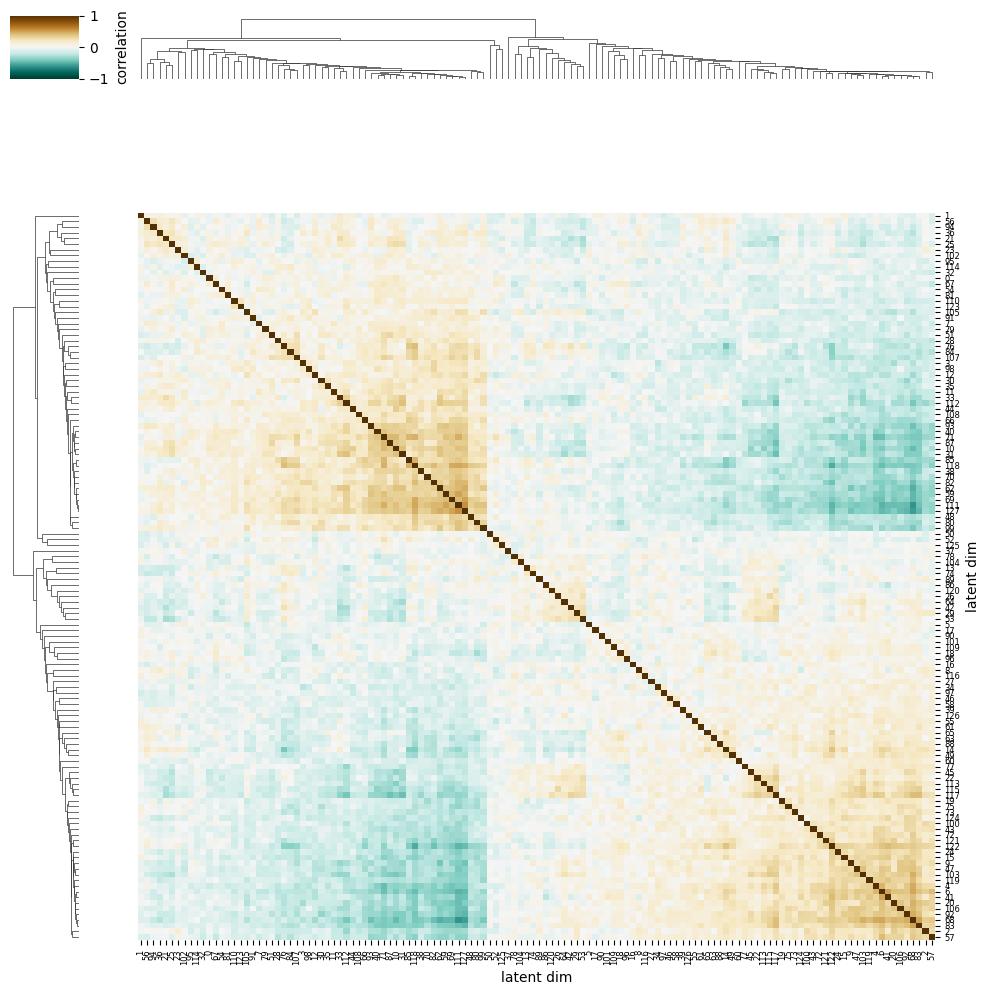

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


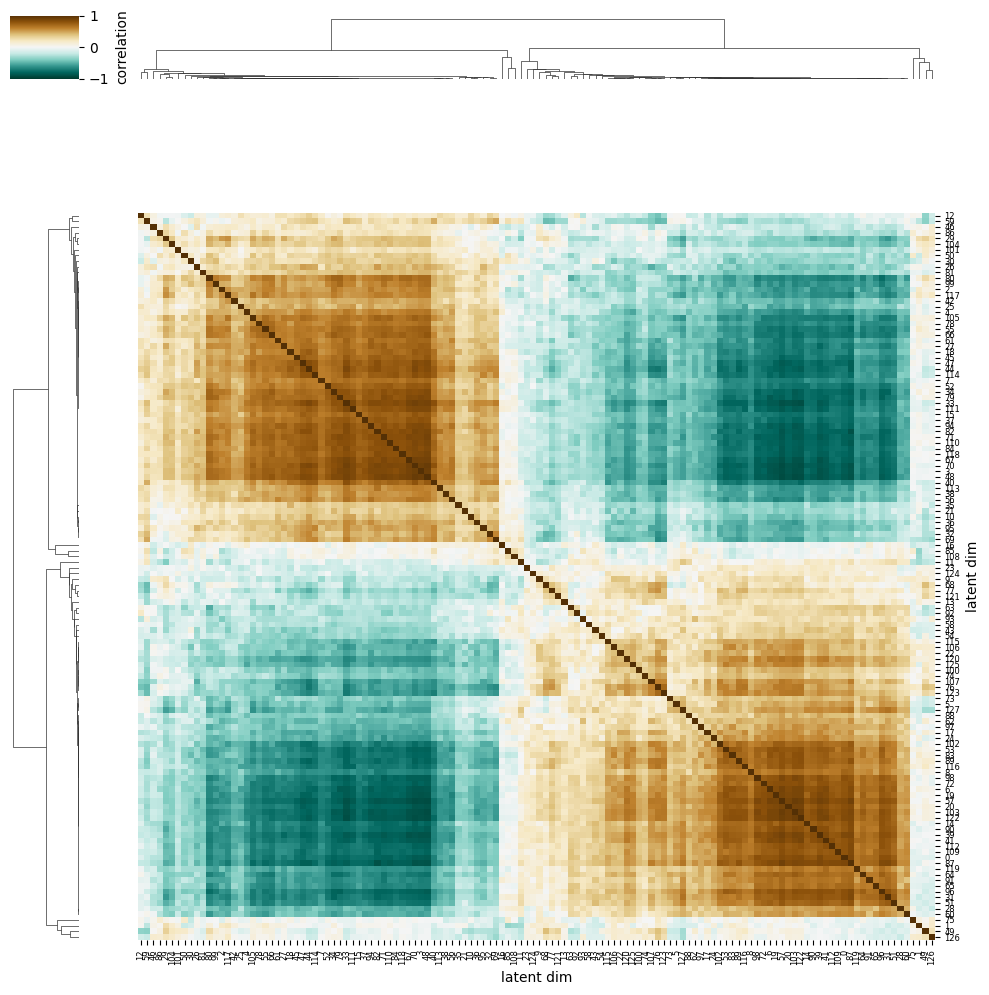

In [17]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result, z_key="_local_emb", vmax=1.0, cmap="BrBG_r",label_fontsize=6)
pl_latent_correlation(result, z_key="_global_emb", vmax=1.0, cmap="BrBG_r",label_fontsize=6)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(952.7777777777777, 0.5, 'local latent dim')

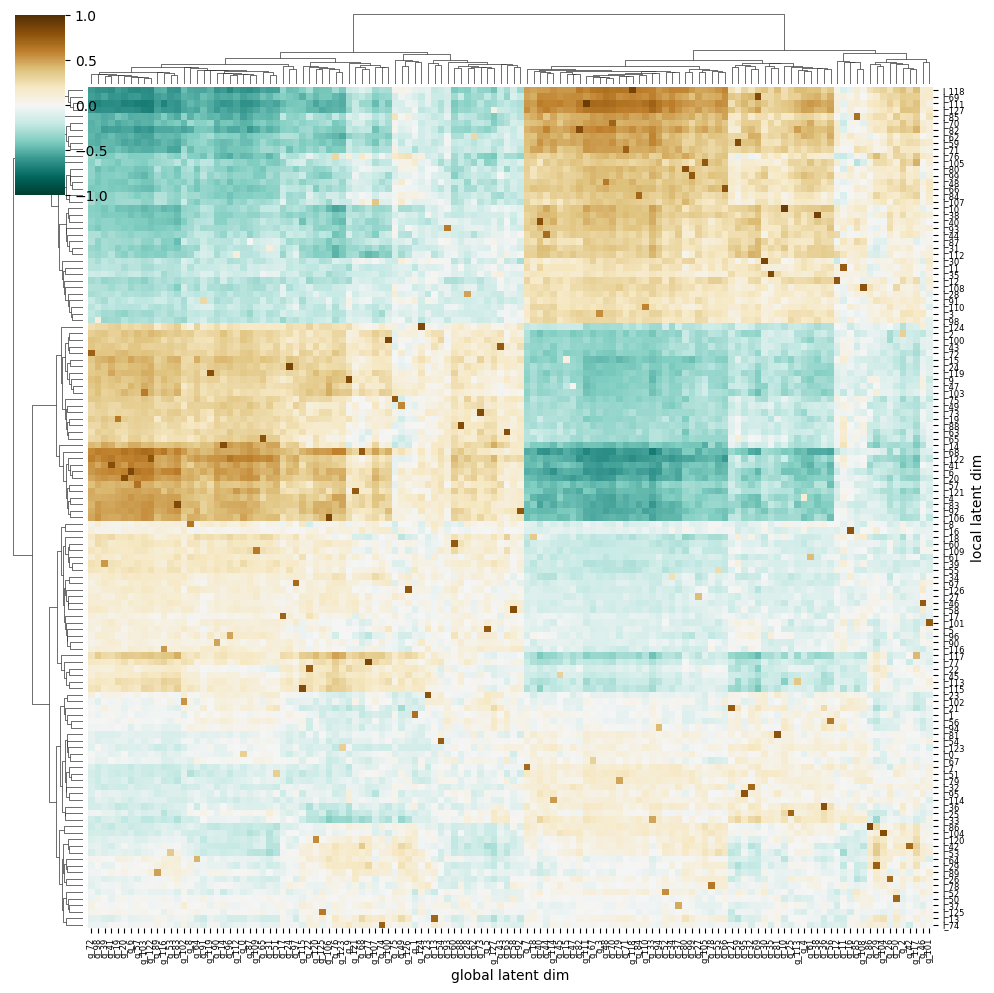

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Z_local = result.obsm["_local_emb"]
Z_global = result.obsm["_global_emb"]

# Standardize each dim across cells
Zl = (Z_local - Z_local.mean(axis=0)) / Z_local.std(axis=0, ddof=1)
Zg = (Z_global - Z_global.mean(axis=0)) / Z_global.std(axis=0, ddof=1)

# Cross-correlation: (L x N) @ (N x G) -> (L x G)
C = (Zl.T @ Zg) / (Zl.shape[0] - 1)

# Labels
row_labels = [f"l_{i}" for i in range(C.shape[0])]
col_labels = [f"g_{j}" for j in range(C.shape[1])]

g = sns.clustermap(
    C,
    dendrogram_ratio=(0.08, 0.08),
    cmap="BrBG_r",
    vmin=-1.0,
    vmax=1.0,
    figsize=(10, 10),
    method="average",
    metric="euclidean",
    xticklabels=col_labels,
    yticklabels=row_labels,
    z_score=None,
    standard_scale=None,
    #cbar_kws={"label": "corr"},
)

# Rotate and resize tick labels
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=6
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=6
)

g.ax_heatmap.set_xlabel("global latent dim")
g.ax_heatmap.set_ylabel("local latent dim")

##### 2. Per-dimension contribution to variance of reconstructed gene expression

Because we're using a linear decoder and we have uncorrelated embedding dimensions then: 

```Var(Ŷ) ~ tr((W^TW)Cov(H))```

In [19]:
from InterScale.evaluation import pl_dim_importance_elbow_stdexpr, get_genes_dim


20% cumulative variance reached with 7 dimensions:
Embedding dimensions (sorted by importance):
[57, 87, 48, 103, 70, 33, 3]


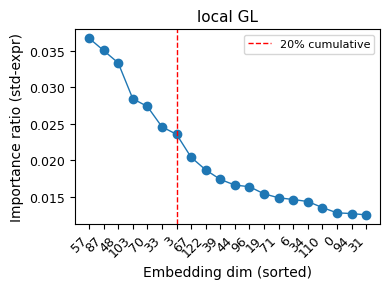

In [22]:
ax = pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.2,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=20,
    figsize=(4, 3),
    fontsize=10,
    title="local GL",
    show=True,
)

In [23]:
ax.figure.savefig("figures/elbow_local.png", dpi=300, bbox_inches="tight")


10% cumulative variance reached with 5 dimensions:
Embedding dimensions (sorted by importance):
[48, 70, 57, 3, 96]


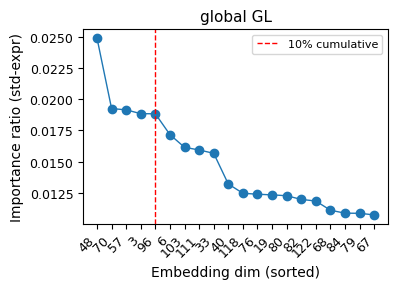

In [25]:
ax = pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.1,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    n_top=20,
    figsize=(4, 3),
    fontsize=10,
    title="global GL",
    show=True,
)

In [26]:
ax.figure.savefig("figures/elbow_global.png", dpi=300, bbox_inches="tight")

##### 3. Gene scoring 

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.  

- Expression filtering:
| Argument   | Effect                               |
| ---------- | ------------------------------------ |
| `X_layer`  | Expression matrix used for filtering |
| `min_frac` | Remove rare genes                    |
| `min_sd`   | Remove low-variance genes            |

- Scoring choices
| Argument                 | Meaning                                |
| ------------------------ | -------------------------------------- |
| `rank_by="loading"`      | Pure decoder sensitivity               |
| `rank_by="loading_x_sd"` | Favor highly variable genes            |
| `residualize=True`       | Use only unique component of dimension |

- Specificity control
| Argument                   | Meaning                              |
| -------------------------- | ------------------------------------ |
| `enforce_specificity`      | Force genes to be dimension-specific |
| `specificity_mode="ratio"` | max/second criterion                 |
| `specificity_min`          | How strict the specificity must be   |

 
gene_by_dim_heatmap interpretation:

So:

Dark brown → strong positive association with that dimension

Dark green → strong negative association

Near white → little association

In [27]:
global_dim = [48, 70, 57, 3, 96]
local_dim = [57, 87, 48, 103, 70, 33, 3]

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/_latent_analysis.py:474: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


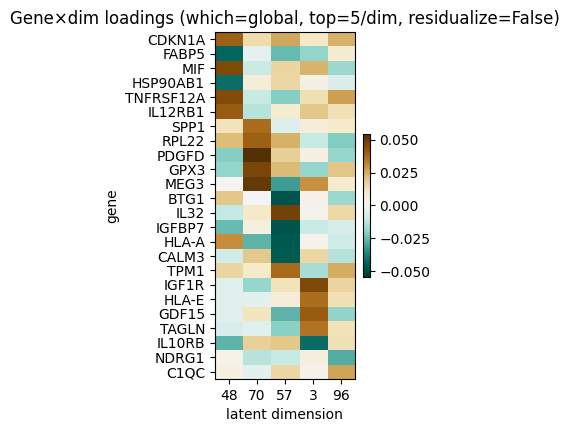

In [31]:
df_global, ax = get_genes_dim(
    result,
    which="global",
    dims=global_dim,
    n_top=5,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    #specificity_min=2.0,
    #residualize=True,
    plot=True,
    figsize=(2, 4.5),
)

In [32]:
ax.figure.savefig("figures/global_genes_dim_plot.png", dpi=300, bbox_inches="tight")

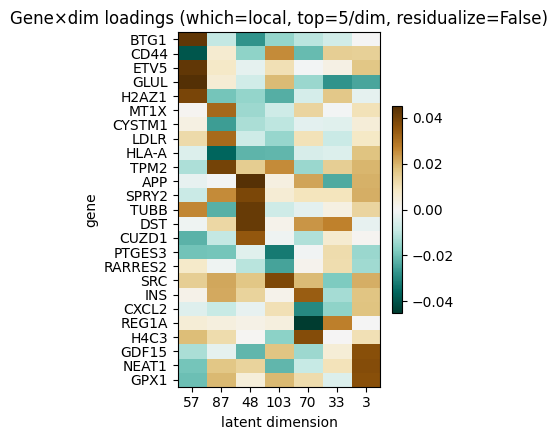

In [34]:
df_local, ax = get_genes_dim(
    result,
    which="local",
    dims=local_dim,
    n_top=5,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    #specificity_min=2.0,
    #residualize=True,
    plot=True,
    figsize=(4, 4.5),
)

In [35]:
ax.figure.savefig("figures/local_genes_dim_plot.png", dpi=300, bbox_inches="tight")

In [36]:
global_genes = df_global.index 
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

Shared: ['BTG1', 'HLA-A', 'GDF15']
Unique local: ['APP', 'CD44', 'CUZD1', 'CXCL2', 'CYSTM1', 'DST', 'ETV5', 'GLUL', 'GPX1', 'H2AZ1', 'H4C3', 'INS', 'LDLR', 'MT1X', 'NEAT1', 'PTGES3', 'RARRES2', 'REG1A', 'SPRY2', 'SRC', 'TPM2', 'TUBB']
Unique global: ['C1QC', 'CALM3', 'CDKN1A', 'FABP5', 'GPX3', 'HLA-E', 'HSP90AB1', 'IGF1R', 'IGFBP7', 'IL10RB', 'IL12RB1', 'IL32', 'MEG3', 'MIF', 'NDRG1', 'PDGFD', 'RPL22', 'SPP1', 'TAGLN', 'TNFRSF12A', 'TPM1']


In [37]:
import squidpy as sq

In [38]:
result.X.max()

4.8127866

In [39]:
local_genes = ['INS', 'REG1A', 'GLUL', 'CD44']
global_genes =  ['SPP1', 'C1QC', 'IL32', 'IGF1R']

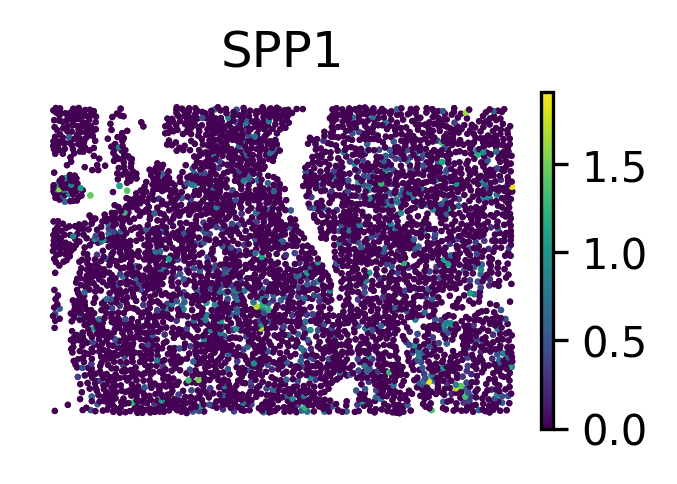

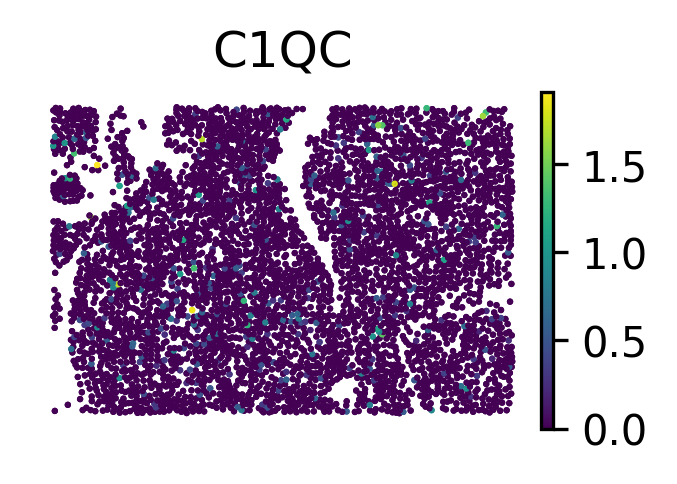

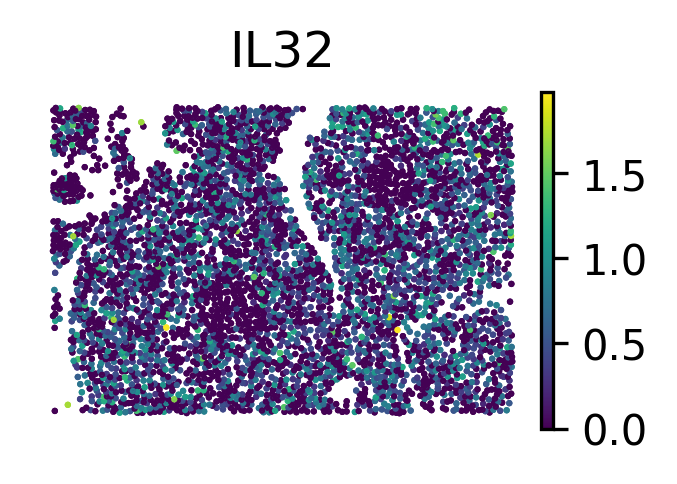

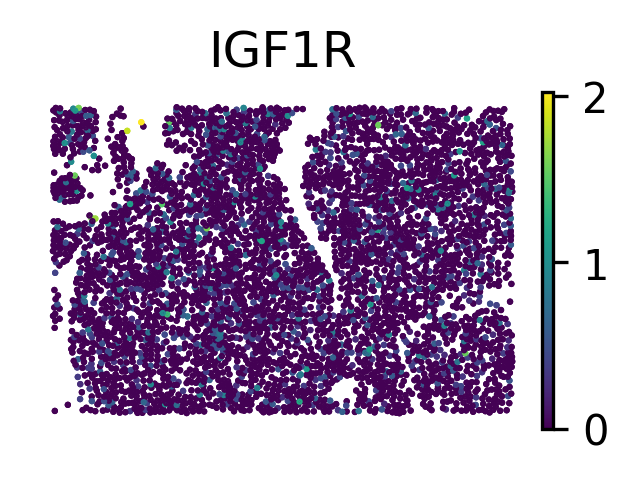

In [46]:
for gene in global_genes:
    sq.pl.spatial_scatter(result[result.obs['slide'] == 'Run5211_S1'], 
                          library_key='fov',
                          library_id=['10'],
                          color = gene,
                          cmap = 'viridis',
                          ncols=1,
                          shape= None, 
                          frameon=False,
                          dpi=300,
                          figsize=(2.5, 1.5),
                          save=f'{gene}_spatial_scatter.png',
                         )

In [47]:
import gseapy as gp

In [48]:
gp.enrichr

<function gseapy.enrichr(gene_list: Union[str, List[str], Tuple[str, ...], pandas.core.series.Series, pandas.core.frame.DataFrame], gene_sets: Union[List[str], str, Dict[str, str]], organism: str = 'human', outdir: Optional[str] = None, background: Union[List[str], int, str] = None, cutoff: float = 0.05, format: str = 'pdf', figsize: Tuple[float, float] = (6.5, 6), top_term: int = 10, no_plot: bool = False, verbose: bool = False) -> gseapy.enrichr.Enrichr>

In [61]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets=["GO_Biological_Process_2025",'WikiPathways_2024_Human'],#'KEGG_2021_Human',"GO_Biological_Process_2025",WikiPathways_2024_Human
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_global.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,WikiPathways_2024_Human,Focal Adhesion PI3K Akt mTOR Signaling WP3932,5/303,0.000013,0.001526,0,0,20.638633,232.394988,CDKN1A;HSP90AB1;PDGFD;SPP1;IGF1R
1,WikiPathways_2024_Human,PI3K Akt Signaling WP4172,5/338,0.000022,0.001526,0,0,18.436562,197.892347,CDKN1A;HSP90AB1;PDGFD;SPP1;IGF1R
2,WikiPathways_2024_Human,FGF23 Signaling In Hypophosphatemic Rickets Re...,2/23,0.000262,0.012233,0,0,100.040100,824.992061,CDKN1A;SPP1
3,WikiPathways_2024_Human,Catabolism Of Skeletal Muscle In Cachexia WP5474,2/40,0.000800,0.019787,0,0,55.238227,393.929167,TNFRSF12A;IGF1R
4,WikiPathways_2024_Human,Oxidative Damage Response WP3941,2/40,0.000800,0.019787,0,0,55.238227,393.929167,CDKN1A;C1QC


In [62]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets=["GO_Biological_Process_2025",'WikiPathways_2024_Human'],
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_local.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Folate Metabolism WP176,3/69,0.000058,0.008580,0,0,47.636364,464.909533,GPX1;LDLR;INS
1,GO_Biological_Process_2025,Selenium Micronutrient Network WP15,3/86,0.000111,0.008580,0,0,37.847178,344.490631,GPX1;LDLR;INS
2,GO_Biological_Process_2025,Oxidative Stress Response WP408,2/33,0.000597,0.030666,0,0,64.345161,477.631046,GPX1;MT1X
3,GO_Biological_Process_2025,Aryl Hydrocarbon Receptor Pathway WP2873,2/45,0.001111,0.033358,0,0,46.360465,315.359146,SRC;PTGES3
4,GO_Biological_Process_2025,Omega 6 Fatty Acids In Senescence WP5424,2/48,0.001264,0.033358,0,0,43.330435,289.179899,GPX1;PTGES3


In [63]:
df_local = enr_local.results
df_global = enr_global.results

In [64]:
top_local = df_local.sort_values("Adjusted P-value").head(8)
top_global = df_global.sort_values("Adjusted P-value").head(8)

In [65]:
df_local["group"] = "Local"
df_global["group"] = "Global"

combined = pd.concat([
    df_local.sort_values("Adjusted P-value").head(8),
    df_global.sort_values("Adjusted P-value").head(8)
])

combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"])

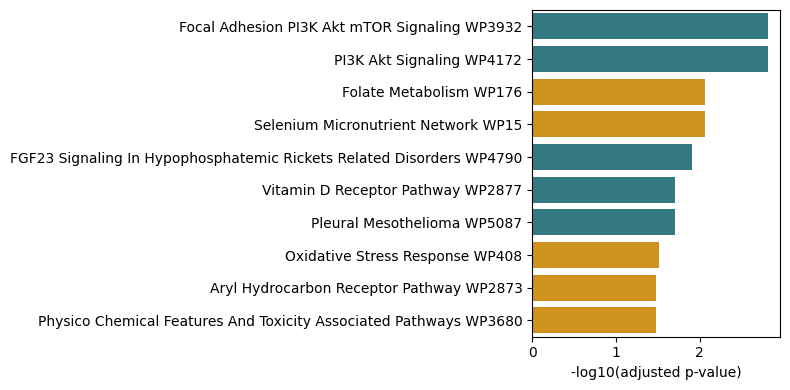

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

combined = combined.sort_values("-log10(padj)", ascending=False)

palette = {
    "Global": "#27828E",
    "Local": "#EE9B00"
}

plt.figure(figsize=(8,4))

sns.barplot(
    data=combined,
    y="Term",
    x="-log10(padj)",
    hue="group",
    palette=palette,
    legend=False
)

plt.xlabel("-log10(adjusted p-value)", fontsize=10)
plt.ylabel("", fontsize=10)
#plt.title("GO enrichment: global vs local embeddings", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#plt.legend(title="", fontsize=10)

plt.tight_layout()
plt.savefig("figures/gene_programs.png", dpi=300, bbox_inches="tight")
plt.show()

##### 4. Moran's I for selected embedding dimensions across multiple spatial radii.

In [67]:
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', '

In [116]:
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

def compute_knn_dependent_morans_i(
    adata,
    emb_key="_global_emb",          # e.g. adata.obsm["_global_emb"] or "_local_emb"
    dims=None,                      # list of dimension indices to analyze, e.g. [0, 3, 7]
    ks=(4, 8, 16, 32, 64),
    coord_type="generic",
    library_key=None,               # e.g. "library_id" if multiple slides/FOVs are in adata.obs
    dim_names=None,
    n_perms=None,                   # e.g. 100 for permutation p-values
    transformation=True,
    copy=False,
):
    """
    Compute Moran's I for selected embedding dimensions across multiple kNN graphs.

    Parameters
    ----------
    adata : AnnData
        AnnData object with:
          - adata.obsm["spatial"] for spatial coordinates
          - adata.obsm[emb_key] for embedding values
    emb_key : str
        Key in adata.obsm containing the embedding matrix of shape (n_cells, n_dims).
    dims : list[int] or None
        List of embedding dimension indices to analyze.
        If None, all dimensions are used.
    ks : iterable[int]
        Numbers of neighbors used to build the spatial kNN graphs.
    coord_type : str
        Usually "generic" for arbitrary coordinates.
    library_key : str or None
        Column in adata.obs identifying slide / library / FOV.
    dim_names : list[str] or None
        Optional custom names for the selected dimensions.
    n_perms : int or None
        Number of permutations for empirical p-values.
    transformation : bool
        Passed to squidpy.gr.spatial_autocorr.
    copy : bool
        Whether to work on a copy of adata.

    Returns
    -------
    moran_df : pd.DataFrame
        Long-format dataframe with one row per (dimension, k).
    """
    if "spatial" not in adata.obsm:
        raise ValueError("adata.obsm['spatial'] is required.")

    if emb_key not in adata.obsm:
        raise ValueError(f"{emb_key!r} not found in adata.obsm.")

    if library_key is not None and library_key not in adata.obs:
        raise ValueError(f"{library_key!r} not found in adata.obs.")

    Z = adata.obsm[emb_key]
    if Z.ndim != 2:
        raise ValueError(f"adata.obsm[{emb_key!r}] must be 2D, got shape {Z.shape}.")

    n_total_dims = Z.shape[1]

    if dims is None:
        dims = list(range(n_total_dims))
    else:
        dims = list(dims)
        if len(dims) == 0:
            raise ValueError("dims must contain at least one dimension index.")
        if min(dims) < 0 or max(dims) >= n_total_dims:
            raise ValueError(f"dims must be between 0 and {n_total_dims - 1}, got {dims}.")

    ks = [int(k) for k in ks]
    if len(ks) == 0 or any(k <= 0 for k in ks):
        raise ValueError("ks must contain positive integers.")

    if dim_names is None:
        dim_names = [f"{emb_key}_dim_{d}" for d in dims]
    else:
        if len(dim_names) != len(dims):
            raise ValueError("dim_names length must match length of dims.")

    ad = adata.copy() if copy else adata

    for name, d in zip(dim_names, dims):
        ad.obs[name] = Z[:, d]

    results = []

    for k in ks:
        sq.gr.spatial_neighbors(
            ad,
            coord_type=coord_type,
            n_neighs=k,
            library_key=library_key,
        )

        sq.gr.spatial_autocorr(
            ad,
            mode="moran",
            genes=dim_names,
            attr="obs",
            transformation=transformation,
            n_perms=n_perms,
        )

        df = ad.uns["moranI"].copy()
        df["dim_name"] = df.index
        df["dim"] = [dims[dim_names.index(name)] for name in df.index]
        df["k"] = k
        results.append(df.reset_index(drop=True))

    moran_df = pd.concat(results, axis=0, ignore_index=True)
    return moran_df


def plot_scale_dependent_morans_i(
    moran_df,
    dims=None,                      # list of dim indices to plot
    dim_names=None,                 # alternatively plot by dim_name
    value_col="I",
    figsize=(4, 3),
    save=None,                      # e.g. "moran_plot.png"
    dpi=300,
):
    """
    Plot Moran's I vs k for selected dimensions.

    Parameters
    ----------
    moran_df : pd.DataFrame
        Output of compute_knn_dependent_morans_i.
    dims : list[int] or None
        Dimension indices to plot.
    dim_names : list[str] or None
        Dimension names to plot.
    value_col : str
        Column to plot on y-axis (default "I").
    figsize : tuple
        Figure size.
    save : str or None
        Path to save the figure (format inferred from extension).
    dpi : int
        DPI used when saving the figure.
    """
    plt.figure(figsize=figsize)

    if dims is not None:
        plot_df = moran_df[moran_df["dim"].isin(dims)]
        group_key = "dim"
    elif dim_names is not None:
        plot_df = moran_df[moran_df["dim_name"].isin(dim_names)]
        group_key = "dim_name"
    else:
        plot_df = moran_df
        group_key = "dim_name"

    for key, sub in plot_df.groupby(group_key):
        sub = sub.sort_values("k")
        plt.plot(sub["k"], sub[value_col], marker="o", label=str(key))

    plt.xlabel("number of neighbors")
    plt.ylabel(f"Moran's I ({value_col})")
    plt.title("k-dependent Moran's I")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=dpi, bbox_inches="tight")

    plt.show()

In [73]:
local_dim, global_dim

([57, 87, 48, 103, 70, 33, 3], [48, 70, 57, 3, 96])

In [68]:
result_s1 = result[result.obs["slide"] == "Run5211_S1"].copy()

In [69]:
result_s1

AnnData object with n_obs × n_vars = 108711 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial', '

In [85]:
moran_global = compute_knn_dependent_morans_i(
    result_s1,
    emb_key="_global_emb",
    dims=global_dim,
    ks=[4, 8, 16, 32, 64],
    coord_type="generic",
    library_key="fov",   # or "sample", "fov", etc.
    n_perms=100,
)

100%|██████████| 100/100 [00:07<00:00, 13.43/s]


In [86]:
moran_local = compute_knn_dependent_morans_i(
    result_s1,
    emb_key="_local_emb",
    dims=local_dim,
    ks=[4, 8, 16, 32, 64],
    coord_type="generic",
    library_key="fov",   # or "sample", "fov", etc.
    n_perms=100,
)

100%|██████████| 100/100 [00:08<00:00, 11.95/s]


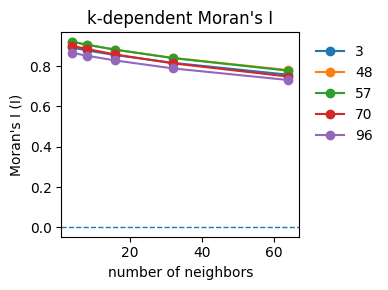

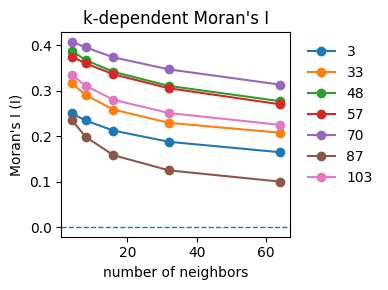

In [117]:
plot_scale_dependent_morans_i(moran_global, dims=global_dim,save='figures/morans_global.png')
plot_scale_dependent_morans_i(moran_local, dims=local_dim,save='figures/morans_local.png')

In [89]:
moran_global.head()

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh,dim_name,dim,k
0,0.921172,0.0,0.000004,0.0,0.009901,0.000008,0.0,0.0,0.009901,_global_emb_dim_48,48,4
1,0.920798,0.0,0.000004,0.0,0.009901,0.000009,0.0,0.0,0.009901,_global_emb_dim_57,57,4
2,0.900686,0.0,0.000004,0.0,0.009901,0.000008,0.0,0.0,0.009901,_global_emb_dim_70,70,4
3,0.892241,0.0,0.000004,0.0,0.009901,0.000008,0.0,0.0,0.009901,_global_emb_dim_3,3,4
4,0.866163,0.0,0.000004,0.0,0.009901,0.000007,0.0,0.0,0.009901,_global_emb_dim_96,96,4


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def summarize_moran_by_radius(
    moran_df,
    label,
    value_col="I",
):
    """
    Compute mean and std of Moran's I across dimensions at each radius.
    """
    required = {"dim", "k", value_col}
    missing = required - set(moran_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    summary = (
        moran_df.groupby("k")[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"count": "n_dims"})
    )
    summary["group"] = label
    return summary[["group", "k", "mean", "std", "n_dims"]]

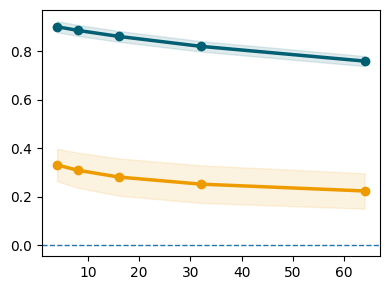

In [92]:
GLOBAL_COLOR = "#005F73"
LOCAL_COLOR  = "#EE9B00"

raw_global = summarize_moran_by_radius(
    moran_global,
    label="global",
    value_col="I",
)

raw_local = summarize_moran_by_radius(
    moran_local,
    label="local",
    value_col="I",
)

plt.figure(figsize=(4,3))

for summary, label, color in [
    (raw_global, "global", GLOBAL_COLOR),
    (raw_local,  "local",  LOCAL_COLOR),
]:

    s = summary.sort_values("k")
    x = s["k"].to_numpy()
    y = s["mean"].to_numpy()
    sd = s["std"].fillna(0).to_numpy()

    plt.plot(
        x, y,
        marker="o",
        linewidth=2.5,
        color=color,
        label=label
    )

    plt.fill_between(
        x,
        y - sd,
        y + sd,
        color=color,
        alpha=0.12
    )

plt.axhline(0, linestyle="--", linewidth=1)

#plt.xlabel("Spatial radius")
#plt.ylabel("Moran's I")
#plt.title("Scale-dependent Moran's I: global vs local embeddings")

#plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/moransI_across_ks.png", dpi=300, bbox_inches="tight")
plt.show()

### Gene rank analysis

In [47]:
ctrl_test.layers['_y_pred_local']

array([[-0.41784543,  0.10436597,  0.15581939, ..., -0.439008  ,
        -0.8869709 , -0.24236163],
       [-0.18968302, -0.21860307, -0.188813  , ..., -0.93693584,
        -0.8444304 , -0.01079343],
       [-0.2361882 ,  0.70588744,  0.231318  , ...,  0.16956502,
        -1.0536482 ,  0.4068437 ],
       ...,
       [-0.27271843, -0.07589218, -0.2681569 , ..., -0.6622197 ,
        -0.46413535, -0.08217128],
       [-0.40162152,  0.41832587, -0.07500255, ..., -0.27980423,
        -1.0338154 , -0.17561972],
       [-0.456762  ,  0.09235121, -0.21919376, ..., -0.6240566 ,
        -0.7109809 , -0.25395873]], dtype=float32)

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


Top 5 genes for _y_pred_local model:
       gene        r2    r2_log  r2_rank
61   OLIG2  0.098329  0.093790     88.0
11    CHAT  0.050963  0.049707     87.0
47    MNX1  0.010942  0.010883     86.0
26   FOXA2  0.009009  0.008969     85.0
53  NKX2.1  0.000000  0.000000     82.5
Top 5 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
25   FOXA1  0.015374  0.015257     88.0
62     OTP  0.007413  0.007385     87.0
53  NKX2.1  0.000000  0.000000     84.5
74    SIX6  0.000000  0.000000     84.5
86   FOXG1  0.000000  0.000000     84.5


/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


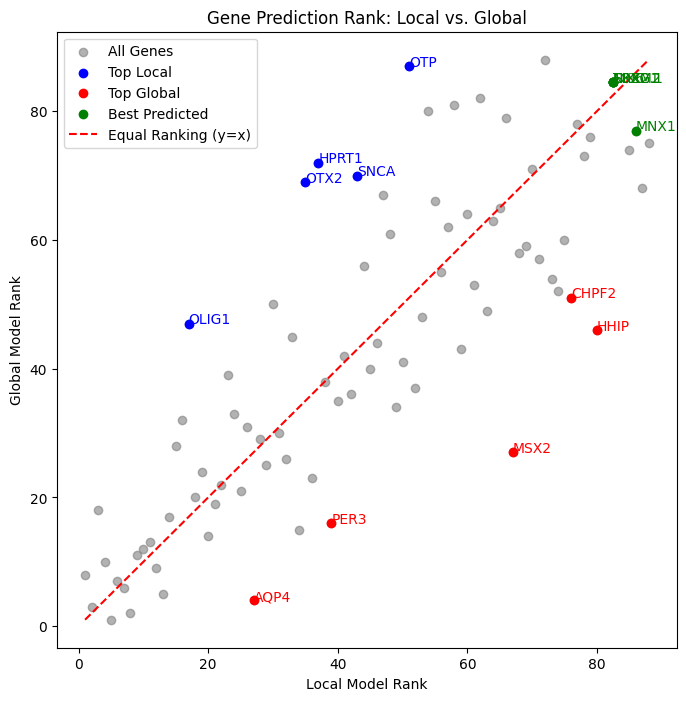

(     gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 62    OTP        51.0         87.0            -36.0      69.0
 38  HPRT1        37.0         72.0            -35.0      54.5
 63   OTX2        35.0         69.0            -34.0      52.0
 60  OLIG1        17.0         47.0            -30.0      32.0
 76   SNCA        43.0         70.0            -27.0      56.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 49   MSX2        67.0         27.0             40.0      47.0
 36   HHIP        80.0         46.0             34.0      63.0
 12  CHPF2        76.0         51.0             25.0      63.5
 4    AQP4        27.0          4.0             23.0      15.5
 67   PER3        39.0         16.0             23.0      27.5,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 53  NKX2.1        82.5         84.5             -2.0      83.5
 74    SIX6        82.5         84.5             -2.0      83.5
 86   FOXG1        82.5         84.5             -

In [48]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(ctrl_test,#result[result.obs['condition'] =='Ctrl'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)

### Cluster by distance 

In [87]:
result

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical', 'z48_global', 'z57_local', 'local_score', 'global_score'
    uns: '_scvi_uuid', '_sc

In [93]:
local_dim, global_dim

([57, 87, 48, 103, 70, 33, 3], [48, 70, 57, 3, 96])

In [95]:
for i in local_dim:
    result_s1.obs[f"z{i}_local"] = result_s1.obsm["_local_emb"][:,i]

for i in global_dim:
    result_s1.obs[f"z{i}_global"] = result_s1.obsm["_global_emb"][:,i]

result_s1

AnnData object with n_obs × n_vars = 108711 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_sample_key_1', '_scvi_group_label', '_cls_horizontal', '_cls_vertical', '_global_emb_dim_48', '_global_emb_dim_70', '_global_emb_dim_57', '_global_emb_dim_3

In [101]:
local2plot = ['z57_local', 'z87_local', 'z48_local', 'z103_local', 'z70_local', 'z33_local', 'z3_local'] 
global2plot = ['z48_global','z70_global', 'z57_global', 'z3_global', 'z96_global']

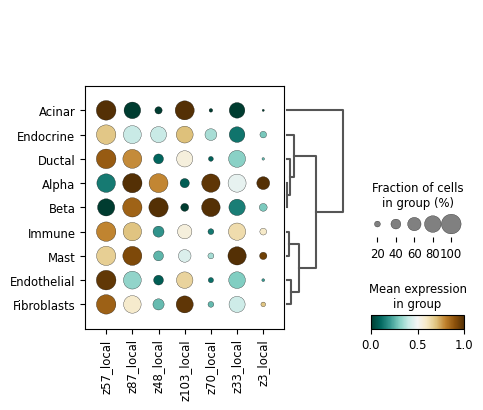

In [107]:
sc.pl.dotplot(result_s1, 
              var_names=local2plot, 
              groupby='cell_type_coarse', 
              standard_scale='var', 
              cmap='BrBG_r', 
              dendrogram=True,
              mean_only_expressed=True
             )

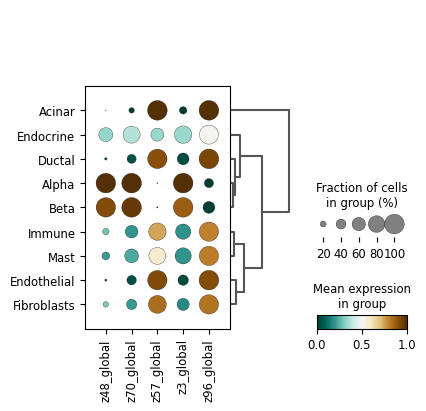

In [108]:
sc.pl.dotplot(result_s1, 
              var_names=global2plot, 
              groupby='cell_type_coarse', 
              standard_scale='var', 
              cmap='BrBG_r', 
              dendrogram=True,
              mean_only_expressed=True
             )